[Google Colab](https://colab.research.google.com/drive/1tvdyzF4fg2vZxLGHWnm9gps1G448p96M?usp=sharing)

In [1]:
!git clone https://github.com/NguyenToanThang-kotaru/NLP-Encoder-Decoder-LSTM-En-Fr.git
DATASET_DIR = "/content/NLP-Encoder-Decoder-LSTM-En-Fr"


fatal: destination path 'NLP-Encoder-Decoder-LSTM-En-Fr' already exists and is not an empty directory.


In [2]:
# Install packages
!pip uninstall -y torch torchtext torchvision torchaudio
!pip install torch==2.2.0
!pip install torchtext==0.17.2
!pip install spacy
!python -m spacy download en_core_web_sm
!python -m spacy download fr_core_news_sm


Found existing installation: torch 2.2.2
Uninstalling torch-2.2.2:
  Successfully uninstalled torch-2.2.2
Found existing installation: torchtext 0.17.2
Uninstalling torchtext-0.17.2:
  Successfully uninstalled torchtext-0.17.2
  Using cached torch-2.2.0-cp312-cp312-manylinux1_x86_64.whl.metadata (25 kB)
Using cached torch-2.2.0-cp312-cp312-manylinux1_x86_64.whl (755.4 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
fastai 2.8.5 requires torchvision>=0.11, which is not installed.
timm 1.0.22 requires torchvision, which is not installed.
  Using cached torchtext-0.17.2-cp312-cp312-manylinux1_x86_64.whl.metadata (7.9 kB)
  Using cached torch-2.2.2-cp312-cp312-manylinux1_x86_64.whl.metadata (25 kB)
Using cached torchtext-0.17.2-cp312-cp312-manylinux1_x86_64.whl (2.0 MB)
Using cached torch-2.2.2-cp312-cp312-manylinux1_x86_64.whl (755.5 MB)
ERROR: pip's dependenc

# LSTM English-to-French

## I. Build the vocab before training the model

### Step 1: Prepare the dataset & tokenize the data

In [3]:
from torchtext.data.utils import get_tokenizer

# Tokenizers
en_tokenizer = get_tokenizer("spacy", language="en_core_web_sm")
fr_tokenizer = get_tokenizer("spacy", language="fr_core_news_sm")

SPECIAL_TOKENS = ["<unk>", "<pad>", "<sos>", "<eos>"]

MAX_VOCAB = 10_004
UNK_TOKEN = "<unk>"

# --- Paths ---
train_file_en = DATASET_DIR+"/Data/train.en"
train_file_fr = DATASET_DIR+"/Data/train.fr"
val_en   = DATASET_DIR+"/Data/val.en"
val_fr   = DATASET_DIR+"/Data/val.fr"
test_en  = DATASET_DIR+"/Data/test_2018_flickr.en"
test_fr  = DATASET_DIR+"/Data/test_2018_flickr.fr"


# --- Function ---
def get_tokens(path, tokenizer):
    all_tokens = []
    with open(path, encoding="utf-8") as f:
        for line in f:
            all_tokens.append(tokenizer(line.strip()))
    return all_tokens

# --- Load tokens ---
enToken = get_tokens(train_file_en, en_tokenizer)
frToken = get_tokens(train_file_fr, fr_tokenizer)

val_en_tokens = get_tokens(val_en, en_tokenizer)
val_fr_tokens = get_tokens(val_fr, fr_tokenizer)

test_en_tokens = get_tokens(test_en, en_tokenizer)
test_fr_tokens = get_tokens(test_fr, fr_tokenizer)






A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.12/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.12/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.12/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.12/dist-package

### Step 2: Build the vocabulary

In [4]:
import torchtext
print(torchtext.__version__)

0.17.2+cpu


In [5]:
from collections import Counter
from torchtext.vocab import build_vocab_from_iterator

# ==== Build vocab function ====

def yield_tokens(token_list):
    for tokens in token_list:
        yield tokens

# ==== English vocab ====

en_vocab = build_vocab_from_iterator(
    yield_tokens(enToken),
    specials=SPECIAL_TOKENS,
    max_tokens=MAX_VOCAB
)

en_vocab.set_default_index(en_vocab[UNK_TOKEN])

# ==== French vocab ====

fr_vocab = build_vocab_from_iterator(
    yield_tokens(frToken),
    specials=SPECIAL_TOKENS,
    max_tokens=MAX_VOCAB
)

fr_vocab.set_default_index(fr_vocab[UNK_TOKEN])

# ==== Check vocab size ====
print("English vocab size:", len(en_vocab))
print("French vocab size:", len(fr_vocab))
print("Two: ",en_vocab(['Two']))
print("Young: ",en_vocab(['young']))

English vocab size: 10004
French vocab size: 10004
Two:  [19]
Young:  [25]


Finally, we have built two vocabularies for the two languages. Each vocabulary contains the 10,000 most frequent words in the dataset, along with four special tokens: <`unk`>, <`pad`>, <`sos`>, and <`eos`>.

## II. Padding & Tracking

### Step 1: Sync the lenght of batch with pad_sequence and pack padded sequence with collate_fn() function

In [6]:
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence
import torch
def collate_fn(batch, src_vocab, tgt_vocab, pad_token='<pad>', sos_token='<sos>', eos_token='<eos>'):
    """
    batch: list of tuples (src_sentence, tgt_sentence)
    src_vocab, tgt_vocab: vocab objects
    """
    src_pad_idx = src_vocab[pad_token]
    tgt_pad_idx = tgt_vocab[pad_token]
    sos_idx = tgt_vocab[sos_token]
    eos_idx = tgt_vocab[eos_token]

    # tách source và target
    src_sentences, tgt_sentences = zip(*batch)

    # chuyển token -> index
    src_indices = [torch.tensor([src_vocab[token] for token in s]) for s in src_sentences]
    # thêm <sos> và <eos> cho target
    tgt_indices = [
        torch.tensor([sos_idx] + [tgt_vocab[token] for token in t] + [eos_idx])
        for t in tgt_sentences
    ]

    # độ dài gốc của source
    src_lengths = torch.tensor([len(seq) for seq in src_indices])

    # pad sequences
    src_padded = pad_sequence(src_indices, batch_first=True, padding_value=src_pad_idx)
    tgt_padded = pad_sequence(tgt_indices, batch_first=True, padding_value=tgt_pad_idx)

    return src_padded, src_lengths, tgt_padded


### Step 2: Initiliazel Dataloader to control for trainning model

In [7]:
from torch.utils.data import DataLoader
from functools import partial
dataset       = list(zip(enToken, frToken))  # enToken = source, frToken = target
val_dataset   = list(zip(val_en_tokens,   val_fr_tokens))
test_dataset  = list(zip(test_en_tokens,  test_fr_tokens))


loader = DataLoader(
    dataset,  # dataset là list zip(enToken, frToken)
    batch_size=128,
    shuffle=True,
    collate_fn=partial(collate_fn, src_vocab=en_vocab, tgt_vocab=fr_vocab)
)

val_loader = DataLoader(
    val_dataset,
    batch_size=128,
    shuffle=False,
    collate_fn=partial(collate_fn, src_vocab=en_vocab, tgt_vocab=fr_vocab)
)

test_loader = DataLoader(
    test_dataset,
    batch_size=128,
    shuffle=False,
    collate_fn=partial(collate_fn, src_vocab=en_vocab, tgt_vocab=fr_vocab)
)


# III. Build the model LSTM

## Encoder class building

In [8]:
import torch.nn as nn

class Encoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, dropout=0.3):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=en_vocab["<pad>"])

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_size,
            num_layers=2,        # Quan trọng!
            dropout=dropout,     # giờ mới có tác dụng
            batch_first=True
        )

    def forward(self, src_batch, src_lengths):
        embedded = self.embedding(src_batch)

        packed = nn.utils.rnn.pack_padded_sequence(
            embedded, src_lengths.cpu(), batch_first=True, enforce_sorted=True
        )

        packed_out, (h, c) = self.lstm(packed)
        return h, c


In [9]:
class Decoder(nn.Module):
    def __init__(self, vocab_size, embed_dim, hidden_size, dropout=0.3, teacher_forcing_ratio=0.5):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=fr_vocab["<pad>"])

        self.lstm = nn.LSTM(
            embed_dim,
            hidden_size,
            num_layers=2,
            dropout=dropout,     # có tác dụng khi num_layers > 1
            batch_first=True
        )

        self.dropout = nn.Dropout(dropout)   # dropout cho embedding hoặc FC

        self.fc = nn.Linear(hidden_size, vocab_size)
        self.teacher_forcing_ratio = teacher_forcing_ratio

    def forward(self, target_ids, h0, c0):
        batch_size, seq_len = target_ids.size()
        vocab_size = self.fc.out_features
        outputs = torch.zeros(batch_size, seq_len, vocab_size, device=target_ids.device)

        input_token = target_ids[:, 0]
        h, c = h0, c0

        for t in range(1, seq_len):
            embedded = self.dropout(self.embedding(input_token)).unsqueeze(1)
            out, (h, c) = self.lstm(embedded, (h, c))
            logits = self.fc(out.squeeze(1))
            outputs[:, t, :] = logits

            teacher = torch.rand(1).item() < self.teacher_forcing_ratio
            input_token = target_ids[:, t] if teacher else logits.argmax(1)

        return outputs

    def decode_step(self, input_token, h, c):
        embedded = self.dropout(self.embedding(input_token)).unsqueeze(1)
        out, (h, c) = self.lstm(embedded, (h, c))
        logits = self.fc(out.squeeze(1))
        return logits, h, c


In [10]:
def evaluate(model, loader, criterion, pad_idx):
    model.eval()
    total_loss = 0.0
    total_tokens = 0

    with torch.no_grad():
        for src_batch, src_lengths, tgt_batch in loader:
            src_batch = src_batch.to(device)
            tgt_batch = tgt_batch.to(device)
            src_lengths = src_lengths.to(device)

            # sort theo length giảm dần
            lengths_sorted, sorted_idx = torch.sort(src_lengths, descending=True)
            src_sorted = src_batch[sorted_idx]
            tgt_sorted = tgt_batch[sorted_idx]

            # ---- SHIFT TARGET ----
            decoder_input = tgt_sorted[:, :-1]   # bỏ <eos>
            target = tgt_sorted[:, 1:]            # bỏ <sos>

            logits = model(src_sorted, lengths_sorted, decoder_input)

            loss = criterion(
                logits.reshape(-1, logits.size(-1)),
                target.reshape(-1)
            )

            num_tokens = (target != pad_idx).sum().item()
            total_loss += loss.item() * num_tokens
            total_tokens += num_tokens

    return total_loss / total_tokens


In [11]:
class Seq2Seq(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src_batch, src_lengths, tgt_batch):
        h, c = self.encoder(src_batch, src_lengths)
        logits = self.decoder(tgt_batch, h, c)
        return logits


In [12]:

device = "cuda" if torch.cuda.is_available() else "cpu"

encoder = Encoder(vocab_size=len(en_vocab), embed_dim=256, hidden_size=512).to(device)
decoder = Decoder(vocab_size=len(fr_vocab), embed_dim=256, hidden_size=512).to(device)

model = Seq2Seq(encoder, decoder).to(device)

pad_idx = fr_vocab["<pad>"]  # hoặc fr_vocab.stoi["<pad>"]
criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)

criterion = nn.CrossEntropyLoss(ignore_index=pad_idx)
optimizer = torch.optim.Adam(model.parameters(), lr=0.0005)
patience = 3
counter = 0
best_loss = float('inf')
patience = 3
counter = 0
train_losses = []
val_losses = []
for epoch in range(20):
    model.train()
    train_loss_total = 0
    train_tokens_total = 0

    for src_batch, src_lengths, tgt_batch in loader:
        src_batch = src_batch.to(device)
        tgt_batch = tgt_batch.to(device)
        src_lengths = src_lengths.to(device)

        lengths_sorted, sorted_idx = torch.sort(src_lengths, descending=True)
        src_sorted = src_batch[sorted_idx]
        tgt_sorted = tgt_batch[sorted_idx]

        optimizer.zero_grad()
        decoder_input = tgt_sorted[:, :-1]
        target = tgt_sorted[:, 1:]

        logits = model(src_sorted, lengths_sorted, decoder_input)

        loss = criterion(
            logits.reshape(-1, logits.size(-1)),
            target.reshape(-1)
        )

        loss.backward()
        optimizer.step()

        # tính loss theo token (ignore padding)
        num_tokens = (tgt_sorted != pad_idx).sum().item()
        train_loss_total += loss.item() * num_tokens
        train_tokens_total += num_tokens

    train_loss = train_loss_total / train_tokens_total

    # truyền pad_idx vào evaluate
    val_loss = evaluate(model, val_loader, criterion, pad_idx)
    train_losses.append(train_loss)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}, train_loss = {train_loss:.4f}, val_loss = {val_loss:.4f}")

    # early stopping
    if val_loss < best_loss:
        best_loss = val_loss
        torch.save(model.state_dict(), "best_seq2seq.pt")
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

    torch.save(model.state_dict(), f"seq2seq_epoch{epoch+1}.pt")


Epoch 1, train_loss = 5.7708, val_loss = 5.3758
Epoch 2, train_loss = 5.2840, val_loss = 4.9483
Epoch 3, train_loss = 4.8213, val_loss = 4.5528
Epoch 4, train_loss = 4.4528, val_loss = 4.2493
Epoch 5, train_loss = 4.1675, val_loss = 4.0895
Epoch 6, train_loss = 3.9171, val_loss = 3.9023
Epoch 7, train_loss = 3.7047, val_loss = 3.7440
Epoch 8, train_loss = 3.5102, val_loss = 3.6433
Epoch 9, train_loss = 3.3341, val_loss = 3.5962
Epoch 10, train_loss = 3.1694, val_loss = 3.4903
Epoch 11, train_loss = 3.0137, val_loss = 3.4096
Epoch 12, train_loss = 2.8736, val_loss = 3.4388
Epoch 13, train_loss = 2.7396, val_loss = 3.4129
Epoch 14, train_loss = 2.6167, val_loss = 3.4109
Early stopping at epoch 14


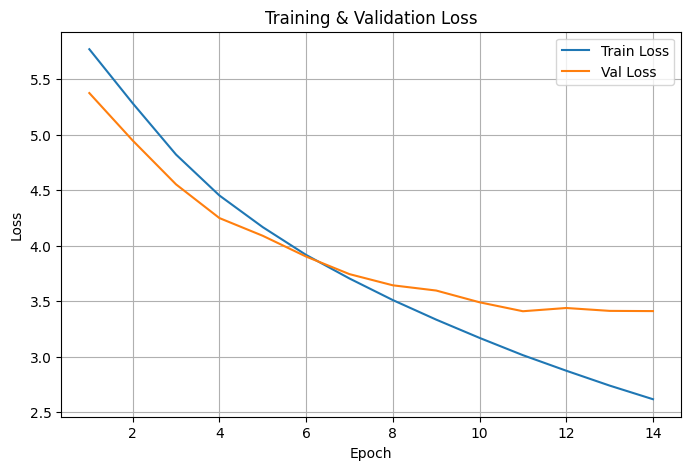

In [13]:
import matplotlib.pyplot as plt

epochs = list(range(1, len(train_losses) + 1))

plt.figure(figsize=(8, 5))
plt.plot(epochs, train_losses, label='Train Loss')
plt.plot(epochs, val_losses, label='Val Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training & Validation Loss")
plt.legend()
plt.grid(True)
plt.show()


In [17]:
def translate(sentence: str) -> str:
    model.load_state_dict(torch.load("best_seq2seq.pt", map_location=device))
    model.eval()
    model.eval()

    tokens = en_tokenizer(sentence)
    stoi = en_vocab.get_stoi()
    src_indices = [stoi.get(tok, stoi["<unk>"]) for tok in tokens]

    src_tensor = torch.tensor([src_indices], dtype=torch.long).to(device)
    src_lengths = torch.tensor([len(src_indices)]).to(device)

    with torch.no_grad():
        h, c = model.encoder(src_tensor, src_lengths)

        sos = fr_vocab["<sos>"]
        eos = fr_vocab["<eos>"]

        input_token = torch.tensor([sos], device=device)
        output = []

        for _ in range(50):
            logits, h, c = model.decoder.decode_step(input_token, h, c)
            next_token = logits.argmax(-1).item()

            if next_token == eos:
                break

            output.append(next_token)
            input_token = torch.tensor([next_token], device=device)

    # indices → tokens
    itos = {v:k for k,v in fr_vocab.get_stoi().items()}
    return " ".join(itos[idx] for idx in output)
# print(translate("go"))
# print(translate("He is going home"))
print(translate("A man drinks water"))
print(translate("Two man"))
print(en_vocab(['Two']))
print(en_vocab(['man']))
# print(en_tokenizer("Two man"))



homme se de l' eau
fonctionnaires fonctionnaires gosses homme .
[19]
[12]


In [19]:
from nltk.translate.bleu_score import corpus_bleu
def evaluate_bleu(model, test_loader):
    model.eval()
    references = []
    hypotheses = []

    itos_fr = {v:k for k,v in fr_vocab.get_stoi().items()}

    with torch.no_grad():
        for src_batch, src_lengths, tgt_batch in test_loader:
            src_batch = src_batch.to(device)
            src_lengths = src_lengths.to(device)

            for i in range(src_batch.size(0)):
                src = src_batch[i]
                length = src_lengths[i].item()

                src_tokens = [
                    en_vocab.lookup_token(idx.item())
                    for idx in src[:length]
                ]

                sentence = " ".join(src_tokens)

                pred = translate(sentence)
                pred_tokens = pred.split()

                # reference: bỏ <sos>, <eos>, <pad>
                ref_tokens = [
                    fr_vocab.lookup_token(idx.item())
                    for idx in tgt_batch[i]
                    if idx.item() not in (
                        fr_vocab["<pad>"],
                        fr_vocab["<sos>"],
                        fr_vocab["<eos>"]
                    )
                ]

                references.append([ref_tokens])
                hypotheses.append(pred_tokens)

    bleu = corpus_bleu(references, hypotheses)
    return bleu
bleu_score = evaluate_bleu(model, test_loader)
print(f"BLEU score on test set: {bleu_score:.4f}")


BLEU score on test set: 0.0764
